# `venn.py` — Syntax Reference

Renders [Mermaid `venn-beta`](https://mermaid.js.org/syntax/venn.html) diagrams using `matplotlib`.

| Feature | Status |
|---|---|
| 2-set diagrams (disjoint / overlapping) | ✅ |
| 3-set diagrams | ✅ |
| `title`, `set`, `union`, `text`, `style` | ✅ |
| `<br/>` line breaks in labels | ✅ |
| Sample-space rectangle (S) | ✅ Always shown |
| Size hints (`:N` suffix) | Parsed, not yet used |

## Setup

In [18]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from libs.venn import venn, Color

---
## 1. Minimal — Two Disjoint Sets

The smallest valid diagram: `venn-beta` header + two `set` statements.

```text
venn-beta
  set A["Label A"]
  set B["Label B"]
```

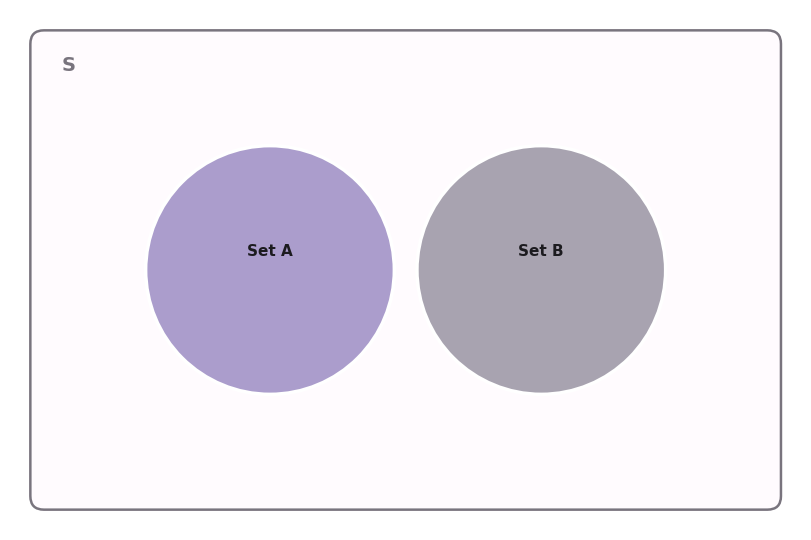

In [19]:
venn("""
venn-beta
  set A["Set A"]
  set B["Set B"]
""")

---
## 2. Title

Add a centered title above the diagram.

```text
venn-beta
  title "My Diagram Title"
  set A["..."]
  ...
```

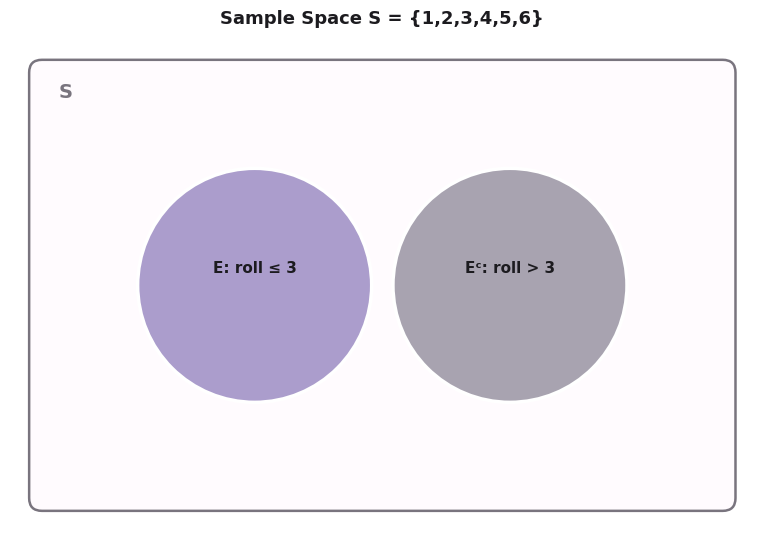

In [20]:
venn("""
venn-beta
  title "Sample Space S = {1,2,3,4,5,6}"
  set E["E: roll ≤ 3"]
  set Ec["Eᶜ: roll > 3"]
""")

---
## 3. Line Breaks in Labels (`<br/>`)

Use `<br/>` inside bracket labels to split text across lines.

```text
set E["Line 1<br/>Line 2"]
```

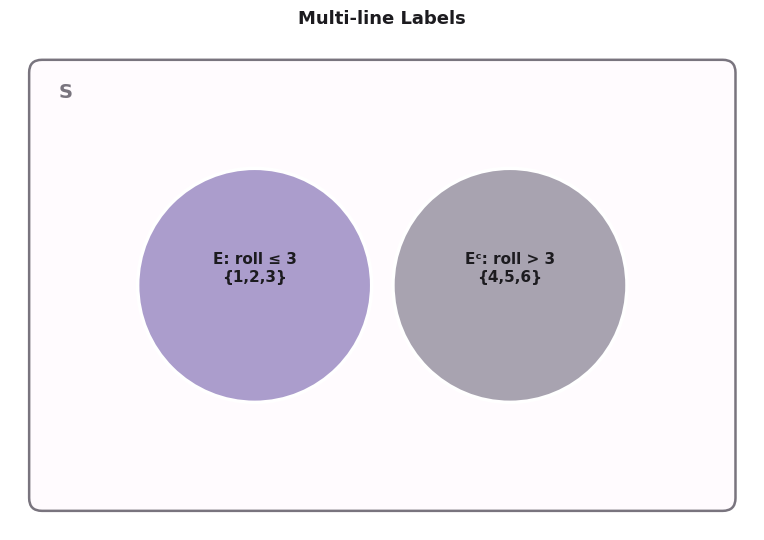

In [21]:
venn("""
venn-beta
  title "Multi-line Labels"
  set E["E: roll ≤ 3<br/>{1,2,3}"]
  set Ec["Eᶜ: roll > 3<br/>{4,5,6}"]
""")

---
## 4. Overlapping Sets with `union`

Declaring a `union` makes the two circles overlap. The union label appears in the intersection region.

```text
venn-beta
  set A["..."]
  set B["..."]
  union A,B["Intersection label"]
```

> Without `union`, sets are drawn **disjoint** (no overlap).

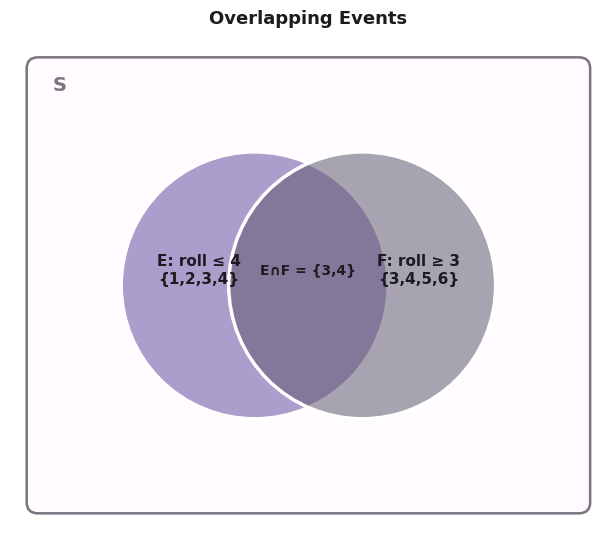

In [22]:
venn("""
venn-beta
  title "Overlapping Events"
  set E["E: roll ≤ 4<br/>{1,2,3,4}"]
  set F["F: roll ≥ 3<br/>{3,4,5,6}"]
  union E,F["E∩F = {3,4}"]
""")

---
## 5. Text Nodes

Add secondary text below a set or union label using `text` (indented under the parent).

```text
set A["Main Label"]
  text a1["secondary text"]
  text a2["another line"]
```

Each `text` node renders below the previous, in a smaller muted font.

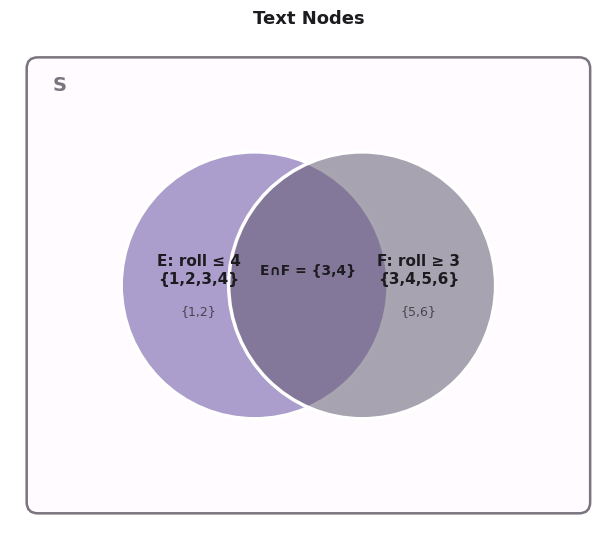

In [23]:
venn("""
venn-beta
  title "Text Nodes"
  set E["E: roll ≤ 4<br/>{1,2,3,4}"]
    text e1["{1,2}"]
  set F["F: roll ≥ 3<br/>{3,4,5,6}"]
    text f1["{5,6}"]
  union E,F["E∩F = {3,4}"]
""")

---
## 6. Styling with `style`

Override default colors per set using CSS-like properties.

| Property | Default | Description |
|---|---|---|
| `fill` | palette color | Circle fill color (hex) |
| `fill-opacity` | `0.55` | Circle fill opacity (0–1) |
| `stroke` | `#ffffff` | Circle border color |
| `stroke-width` | `2.5` | Circle border width (px) |
| `color` | `#1e293b` | Label text color |

```text
style <set-id> fill:#hex,fill-opacity:0.6
```

> Multiple properties are space-separated: `fill:#ff6b6b fill-opacity:0.7`

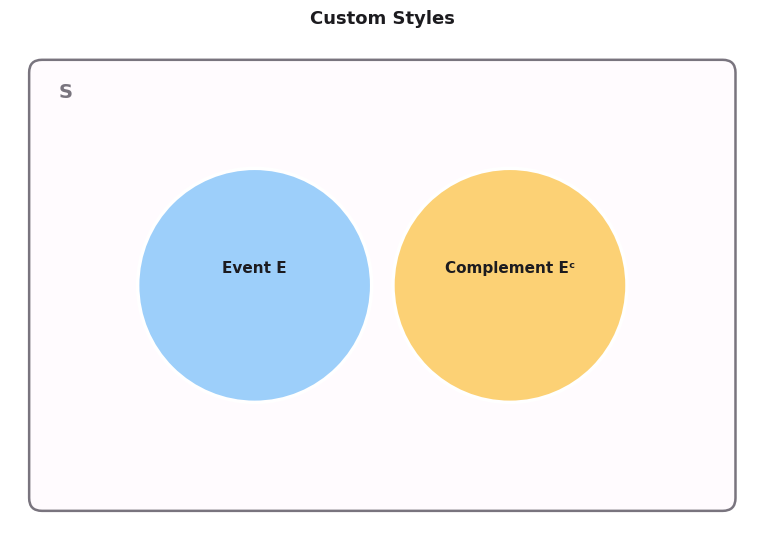

In [24]:
venn("""
venn-beta
  title "Custom Styles"
  set E["Event E"]
  set Ec["Complement Eᶜ"]
  style E fill:#4dabf7
  style Ec fill:#fab005
""")

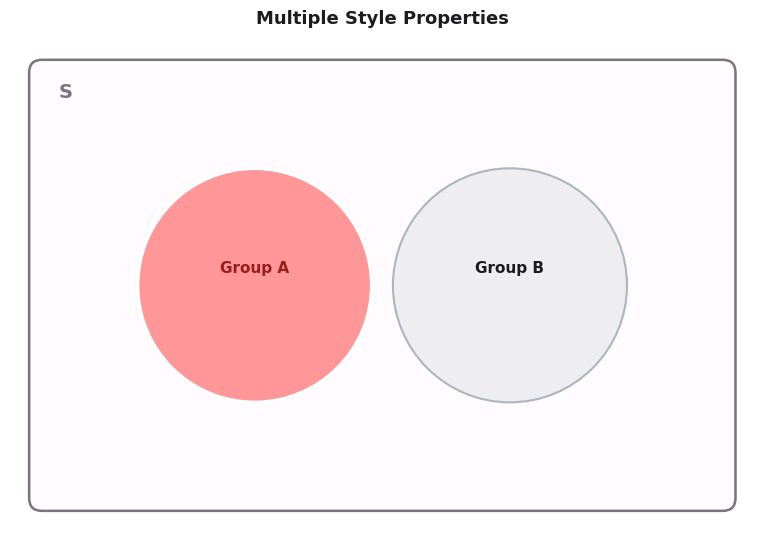

In [25]:
venn("""
venn-beta
  title "Multiple Style Properties"
  set A["Group A"]
  set B["Group B"]
  style A fill:#ff6b6b,fill-opacity:0.7,color:#991b1b
  style B fill:#dee2e6,fill-opacity:0.5,stroke:#adb5bd,stroke-width:1.5
""")

---
## 7. Subset Pattern (E ⊆ F)

Show a subset relationship by using `union` where the intersection equals the smaller set.

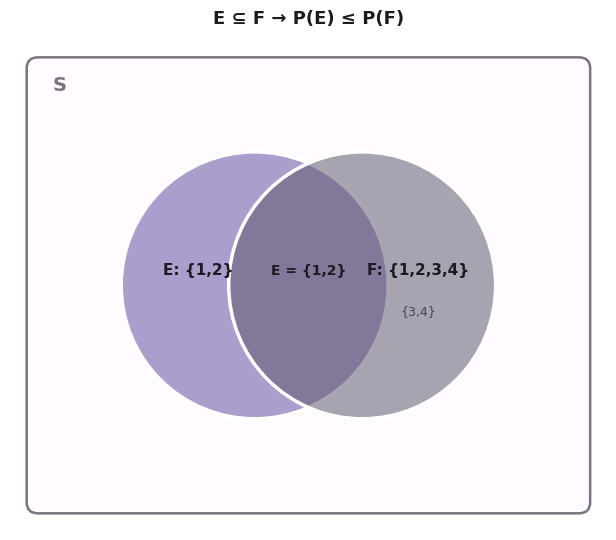

In [26]:
venn("""
venn-beta
  title "E ⊆ F → P(E) ≤ P(F)"
  set E["E: {1,2}"]
  set F["F: {1,2,3,4}"]
    text f1["{3,4}"]
  union E,F["E = {1,2}"]
""")

---
## 8. Three Sets

Pass three `set` statements for a 3-circle layout.

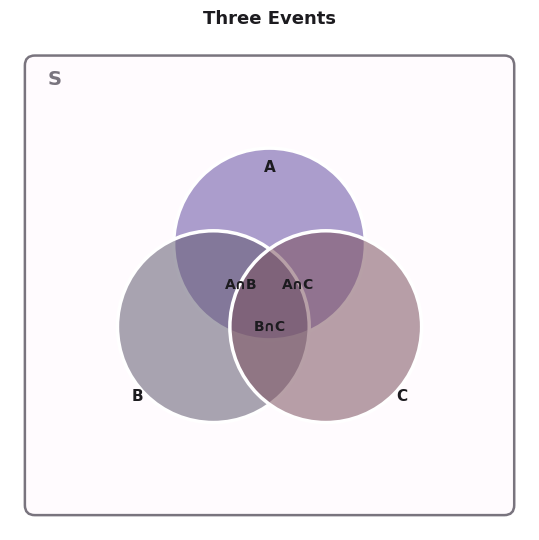

In [27]:
venn("""
venn-beta
  title "Three Events"
  set A["A"]
  set B["B"]
  set C["C"]
  union A,B["A∩B"]
  union B,C["B∩C"]
  union A,C["A∩C"]
""")

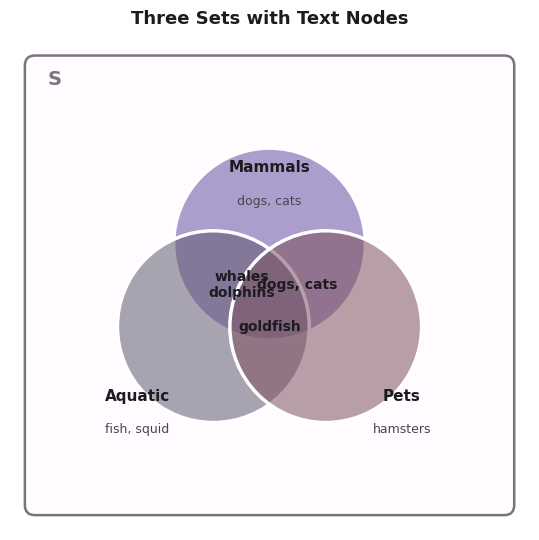

In [28]:
venn("""
venn-beta
  title "Three Sets with Text Nodes"
  set A["Mammals"]
    text a1["dogs, cats"]
  set B["Aquatic"]
    text b1["fish, squid"]
  set C["Pets"]
    text c1["hamsters"]
  union A,B["whales<br/>dolphins"]
  union B,C["goldfish"]
  union A,C["dogs, cats"]
""")

---
## 9. Full Syntax Grammar

```ebnf
diagram     ::= 'venn-beta' NL statement*
statement   ::= title | set_decl | union_decl | text_decl | style_decl

title       ::= 'title' '"' TEXT '"'
set_decl    ::= 'set' ID [ '["' LABEL '"]' ] [ ':' SIZE ]
union_decl  ::= 'union' ID_LIST [ '["' LABEL '"]' ] [ ':' SIZE ]
text_decl   ::= 'text' ID [ '["' TEXT '"]' ]
style_decl  ::= 'style' ID_OR_LIST PROP*

ID          ::= [a-zA-Z_][a-zA-Z0-9_]*
ID_LIST     ::= ID ( ',' ID )*
LABEL       ::= TEXT  (* may contain <br/> for line breaks *)
SIZE        ::= [0-9]+  (* parsed but reserved for future use *)
PROP        ::= KEY ':' VALUE
KEY         ::= 'fill' | 'fill-opacity' | 'stroke' | 'stroke-width' | 'color'
VALUE       ::= [^\s,]+
```

**Rules:**
- `venn-beta` must be the first non-empty line
- `text` nodes attach to the most recent `set` or `union`
- Without any `union`, 2-set diagrams render as **disjoint circles**
- With a `union`, 2-set diagrams render as **overlapping circles**
- Indentation is optional (cosmetic only)
- 2 or 3 sets are supported

### Python API

```python
venn(diagram: str,
     color_scheme: Color | None = None,
     figsize: tuple[float, float] | None = None)
```

| Parameter | Type | Default | Description |
|---|---|---|---|
| `diagram` | `str` | *(required)* | Mermaid `venn-beta` syntax string |
| `color_scheme` | `Color \| None` | `Color.BASELINE` | Material Design palette enum |
| `figsize` | `tuple[float, float] \| None` | `(9, 5.5)` | Figure size in inches `(width, height)` |

---
## 10. Default Color Palette

When no `style` is specified, sets cycle through:

| Index | Color | Hex |
|---|---|---|
| 0 | 🟣 Indigo | `#6366f1` |
| 1 | 🟡 Amber | `#f59e0b` |
| 2 | 🟢 Emerald | `#10b981` |

The sample space box uses `#f8fafc` fill with `#94a3b8` border.

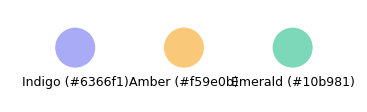

In [29]:
# Show the default palette
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

colors = {'Indigo (#6366f1)': '#6366f1', 'Amber (#f59e0b)': '#f59e0b', 'Emerald (#10b981)': '#10b981'}
fig, ax = plt.subplots(figsize=(6, 1.2))
for i, (name, c) in enumerate(colors.items()):
    ax.add_patch(plt.Circle((1 + i * 2, 0.5), 0.4, fc=to_rgba(c, 0.55), ec='white', lw=2.5))
    ax.text(1 + i * 2, -0.2, name, ha='center', fontsize=9)
ax.set_xlim(-0.2, 6.2)
ax.set_ylim(-0.5, 1.2)
ax.set_aspect('equal')
ax.axis('off')
plt.show()